In [116]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import datetime
import matplotlib
from matplotlib import dates as mdates

matplotlib.rcParams["font.size"] = 20
matplotlib.rcParams["lines.linewidth"] = 3
matplotlib.rcParams["mathtext.default"] = 'regular'
matplotlib.rcParams['lines.markersize'] = 3

#Colour blind friendly colour palette to cycle through the different data sets
colourCycle = ['#377eb8', '#ff7f00', '#4daf4a',
              '#f781bf', '#a65628', '#984ea3',
              '#999999', "#e70004", "#8b8b02"]

#Dictionary to label all the channels appropriately, assign them a unique colour and marker. 
Detectors = {'Ch_4': ["LSC Left",colourCycle[0],"o"],
             'Ch_5': ["LSC Right",colourCycle[1],"v"],
             'Ch_8': ["NaI 1",colourCycle[2],"^"],
             'Ch_10': ["NaI 2",colourCycle[3],"<"],
             'Ch_12': ["NaI 3",colourCycle[4],"P"],
             'Ch_14': ["NaI 4",colourCycle[5],"s"]
             }

In [117]:
class ProfileHistData:
    # This class stores all of the data for a given detector.
    
    def __init__(self,ch):
        self.ch = ch
        self.data = []
        self.chLabel = f'{Detectors[f'Ch_{self.ch}'][0]} Profile Hist Fit'
        
        self.scaleFactors = []
        self.scaleFactorsErr = []
        self.dates = []
        
        self.colours = Detectors[f'Ch_{self.ch}'][1]
        self.marker = Detectors[f'Ch_{self.ch}'][2]
    
    def addFitResults(self,fitResults):
        self.data.append(fitResults)
        self.scaleFactors.append(fitResults.scaleFactor)
        self.scaleFactorsErr.append(fitResults.scaleFactorErr)
        self.dates.append(fitResults.date)
        
    def plotData(self,ax):
        ax.scatter(self.dates,self.scaleFactors,color = self.colours, marker = self.marker, label = self.chLabel,s = 50)
        ax.errorbar(self.dates,self.scaleFactors,yerr = self.scaleFactorsErr,color = self.colours, marker = self.marker,linestyle = 'None')
        
        
class fitData:
    #This class is designed to be a container to hold the individual information about each channels fits. 
    
    def __init__(self,ch,scaleFactor,scaleFactorErr,date):
        self.ch = ch
        self.scaleFactor = scaleFactor
        self.scaleFactorErr = scaleFactorErr
        self.date = date
        
    

In [118]:
def ReadInProfileData(filepath):
    #Currently only reading in all the 
    gammaEnergy = 662 #keV
    chResults,totalData = [],[] #chResults is the list of all fitData. totalData is the histogram of ProfileHistData
    Channels = [4,5,8,10,12,14]
    
    for ch in Channels: #initialize each ProfileHistData instance for each 
        totalData.append(ProfileHistData(ch))
        
    for file in filepath:
        
        with open(file) as f:
            next(f) #skips the header of the file. 
            for line in f:
                data = line.split(",")
                time = datetime.datetime(int(data[0].split("_")[0]),int(data[0].split("_")[1]),int(data[0].split("_")[2]))
                channels = [int(data[1]),int(data[2])]
                p0 = float(data[8])
                p0Err = float(data[9])
                p1 = float(data[10])
                p1Err = float(data[11])
                
                
                #note: the x axis is always the liquid scintillator, and corresponds to the first channel listed. 
                #      The second channel is always the NaI detectors, and corresponds to the second channel listed. 
                xInt = -p0/p1
                yInt = p0
                
                xIntErr = xInt*np.sqrt((p0Err/p0)**2 + (p1Err/p1)**2)
                yIntErr = p0Err
        
                if channels[0] == 4 and channels[1] == 5:
                    continue
                else:
                    #(self,ch,scaleFactor,scaleFactorErr,date):
                    chResults.append(fitData(channels[0],xInt/662,xIntErr/662,time)) #Save all the data in the LSC to a fitData object.
                    chResults.append(fitData(channels[1],yInt/662,yIntErr/662,time)) #Save all the data in the NaI to a fitData object.
                    
                    for totD in totalData: 
                        if chResults[-1].ch == totD.ch:
                            totD.addFitResults(chResults[-1])
                        if chResults[-2].ch == totD.ch:
                            totD.addFitResults(chResults[-2])
                            
    return chResults, totalData


def ReadInInitData(filepath):
    with open(filepath) as f:
        for i in range(1):
            next(f) #Skip the header
            
        for line in f:
            data = line.split(',')
            LPMT = float(data[0])
            LPMTErr = float(data[1])
            
            RPMT = float(data[2])
            RPMTErr = float(data[3])
            
    return [LPMT,LPMTErr], [RPMT,RPMTErr]

In [125]:
rootFilePath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/') #This is the filepath to the overall directory that holds all the calibration data. 
ResultsFilePaths = rootFilePath.rglob('*_Profile_hist_fit_results.txt')

LPMT, RPMT = ReadInInitData('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/Loaded_BNL_L_LSC_Small_NaI_LY_coinc_2/RAW/SDataR_Loaded_BNL_L_LSC_Small_NaI_LY_coinc_2/figures/SDataR_Loaded_BNL_L_LSC_Small_NaI_LY_coinc_2_scale_factors.txt')

chResults, totalData = ReadInProfileData(ResultsFilePaths)

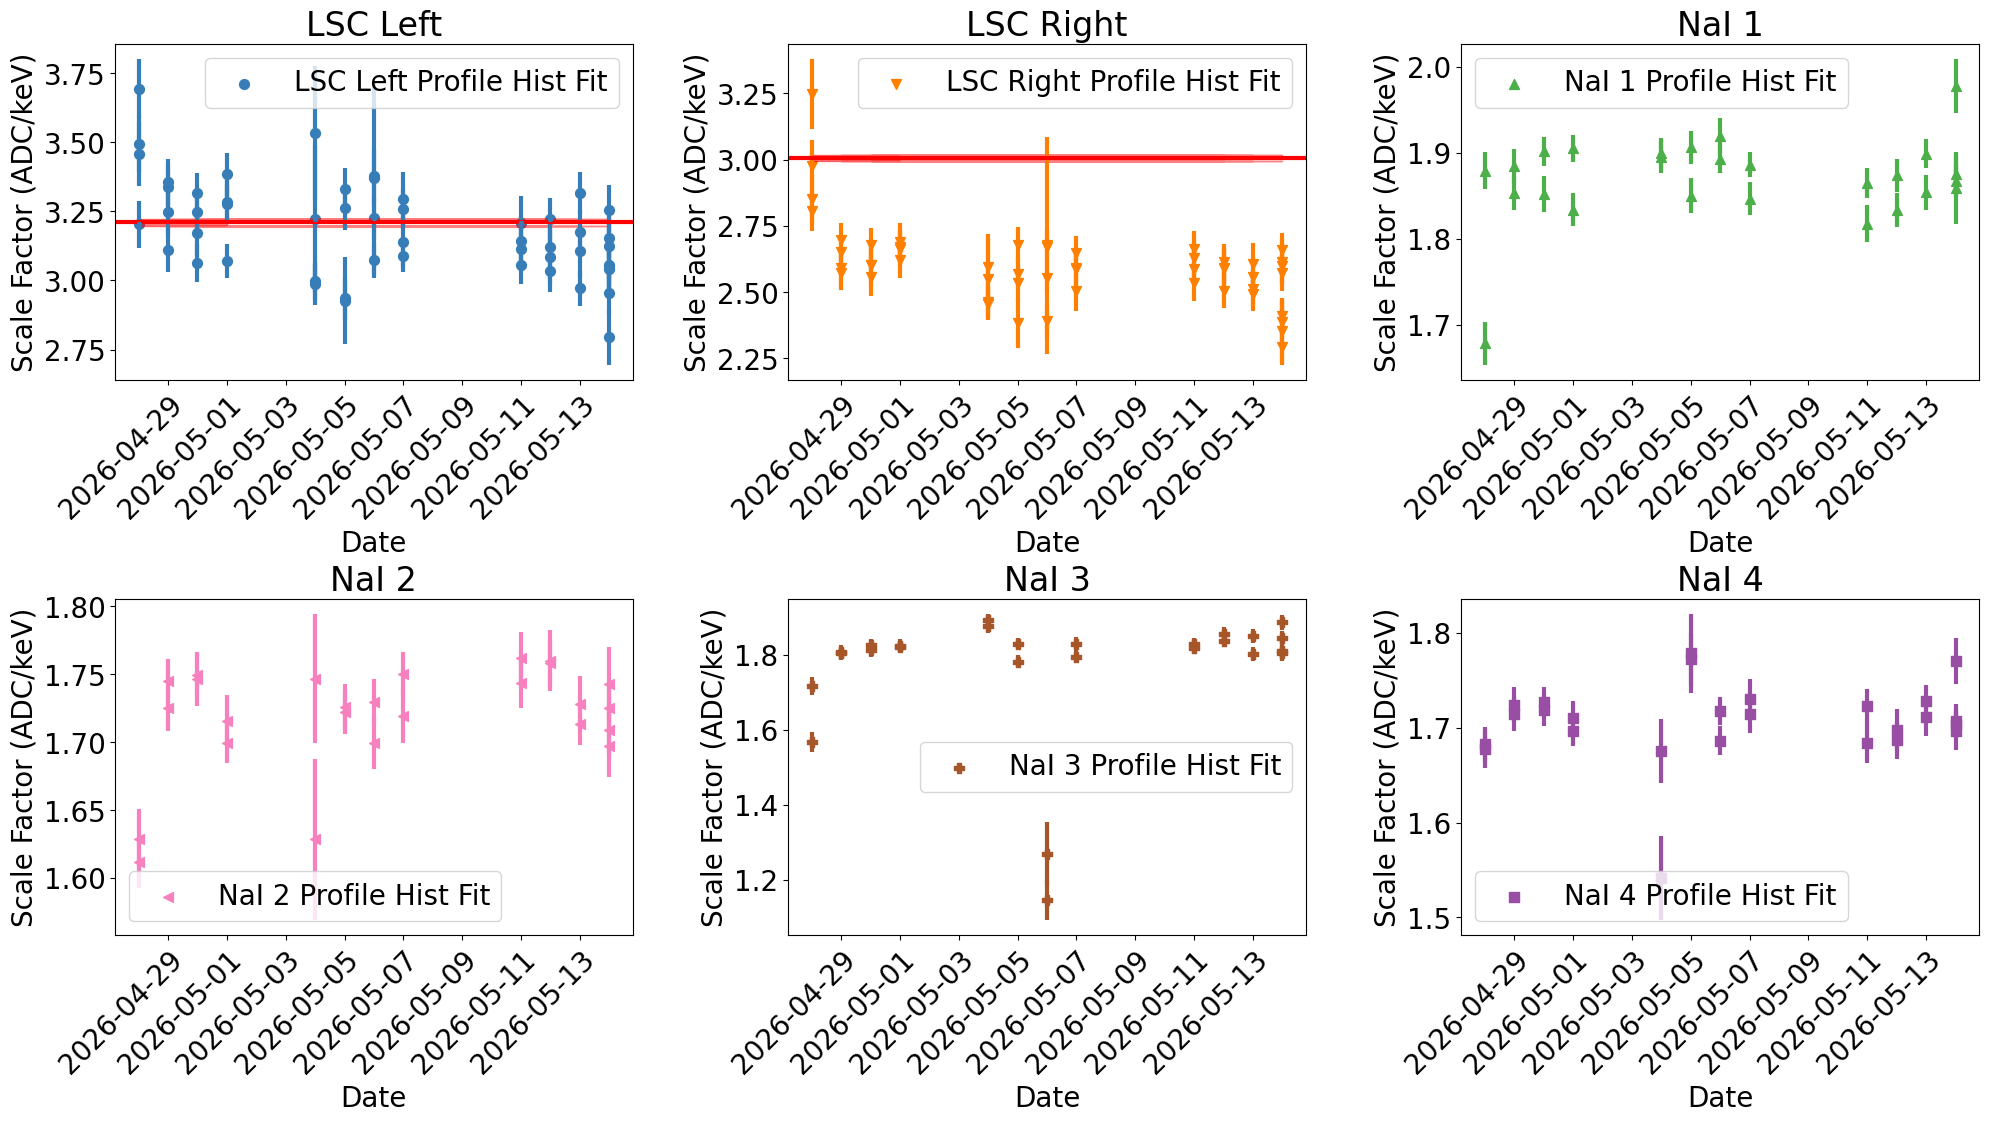

In [126]:
fig,ax = plt.subplots(2,3,figsize = (20,10))
plt.tight_layout()
plt.subplots_adjust(hspace = 0.65,wspace = 0.3)

channels = [4,5,8,10,12,14]
axesNum = [ax[0,0],ax[0,1],ax[0,2],ax[1,0],ax[1,1],ax[1,2]]
for data in totalData:
    axes = axesNum[channels.index(data.ch)]        
        
    data.plotData(axes)
    
ax[0,0].axhline(LPMT[0], color = 'red')
ax[0,0].fill_between(x = totalData[0].dates,y1=LPMT[0]+LPMT[1], y2=LPMT[0]-LPMT[1], color='red',  interpolate=True, alpha=.5)

ax[0,1].axhline(RPMT[0], color = 'red')
ax[0,1].fill_between(x = totalData[0].dates,y1=RPMT[0]+RPMT[1], y2=RPMT[0]-RPMT[1], color='red',  interpolate=True, alpha=.5)
    
# labels = totalData[0].dates    

for i,axs in enumerate(axesNum):
    axs.set_title(f'{Detectors[f'Ch_{channels[i]}'][0]}')   
    axs.set_xlabel('Date')
    axs.set_ylabel('Scale Factor (ADC/keV)')
    axs.legend(loc = 'best')
    
    # Format x-axis to show only YYYY-MM-DD
    axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.setp(axs.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    # ax.set_xticks(ticks)
    # axs.set_xticklabels(labels, rotation=45, ha='right', rotation_mode='anchor')
    # axs.tick_params(axis='x', labelrotation=45,ha='right')
    
# plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.show()
